# High Fidelity Neural Network
Neural Network which uses HF dataset and exploits the High fidelity component of the MF model  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax

from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf


from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


Ray module not found. Multiprocessing features are not available


True

In [2]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data preparation

In [3]:
# import of the train data
# st.Venant constitutive law for the HF data

mu_train_HF = np.loadtxt("../DATA_shear/Data_Train_bases_short/mu_train_HF.txt")
U_hf_train = np.loadtxt("../DATA_shear/Data_Train_bases_short/Uhf_train.txt")

In [4]:
# import of the test data
# st.Venant constitutive law for the HF data

mu_test = np.loadtxt("../DATA_shear/Data_Test_bases/mu_test.txt")
U_hf_test = np.loadtxt("../DATA_shear/Data_Test_bases/Uhf_test.txt")
mu_max = np.loadtxt("../DATA_shear/Data_Test_bases/mu_max.txt")
mu_min = np.loadtxt("../DATA_shear/Data_Test_bases/mu_min.txt")

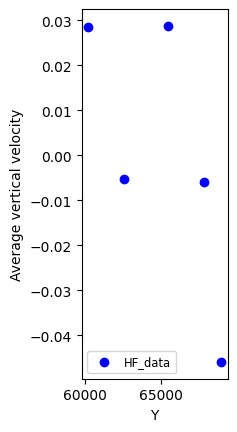

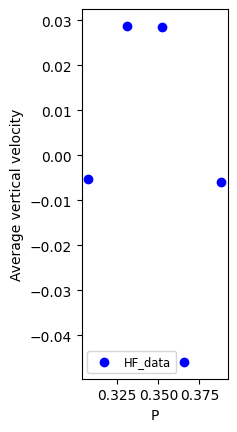

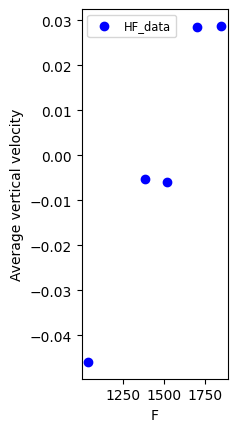

In [5]:
plt.subplot(1, 3, 1)
plt.scatter(mu_train_HF[:,0], U_hf_train-np.mean(U_hf_train), label='HF_data', color='blue', marker='o')
plt.xlabel('Y')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

plt.subplot(1, 3, 2)
plt.scatter(mu_train_HF[:,1], U_hf_train-np.mean(U_hf_train), label='HF_data', color='blue', marker='o')
plt.xlabel('P')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

plt.subplot(1, 3, 3)
plt.scatter(mu_train_HF[:,2], U_hf_train-np.mean(U_hf_train), label='HF_data', color='blue', marker='o')
plt.xlabel('F')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

In [6]:
U_hf_train=U_hf_train-np.mean(U_hf_train)

U_hf_test=U_hf_test-np.mean(U_hf_test)


mu_test=(mu_test-mu_min)/(mu_max-mu_min)
mu_train_HF=(mu_train_HF-mu_min)/(mu_max-mu_min)


In [7]:
Nhf = 4
U_HF_list = []
NepoHF=2000

r2_HF_df = pandas.DataFrame(columns=['NB.basis','R2'])  # dataframe which stores HF R^2
mse_HF_df = pandas.DataFrame(columns=['NB.basis','MSE'])  # dataframe which stores HF MSE


## Neural Network
Cycle on the Discretization and the value of the diffusion 

In [8]:
# Name of the folder
folder_name = "HF_model"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")

test_mse_HF_list = []

r2_HF_list = []

permutation = np.random.permutation(len(mu_train_HF))
mu_HF = mu_train_HF[permutation,:][0:Nhf,:]
U_HF = U_hf_train[permutation][0:Nhf]

Folder 'HF_model' already exists.


In [9]:
name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00012051711558537875, 'lr': 0.0017624104175516413, 'nodes': 18.0, 'opt': 'Adamax'}



HF Model:


The function training took 4.065117597579956 seconds.


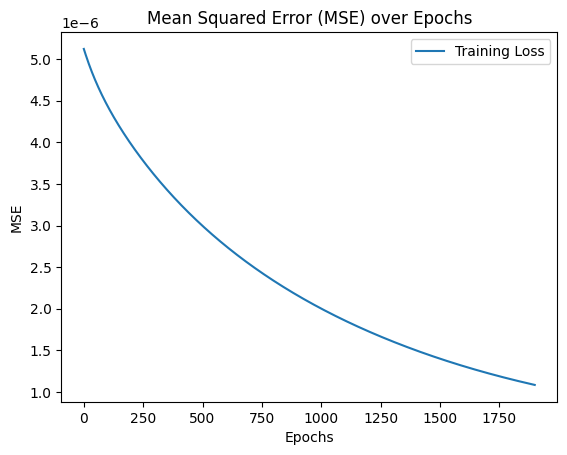

Test MSE: 6.123211551516853e-06
R^2: 0.9909199348317083
saving the model ...


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Shear_NN\../utils\Structure.py:203: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model,folder)


In [10]:
print("\nHF Model:")

model= NetworkFactory.build_network("HF",params=best_params,data_train=mu_HF,output_train=U_HF,N=NepoHF,n=Nhf,do_HPO=False,verbose=False)
UHF = model.prediction(mu_test)

(mse_HF,R_HF) = model.performance(mu_test,U_hf_test)
model.save(place=folder_path)

# POST PROCESSING

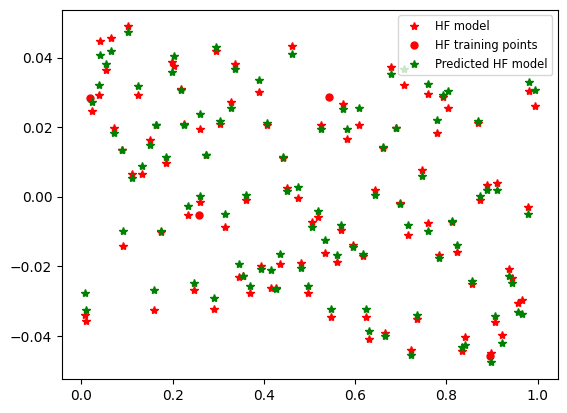

In [11]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(mu_test[:,0], U_hf_test, "r*", linewidth=1.5, label="HF model")
plt.plot(mu_HF[:,0], U_HF, "ro", markersize=5, label="HF training points")
plt.plot(
    mu_test[:,0],
    model.prediction(mu_test),
    "g*",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

In [12]:
########################     SAVE the OUTPUT      ##########################

os.makedirs("HF_model_shear_cube")

R2_HF = pandas.DataFrame({"R2_HF": [R_HF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [mse_HF]})


# R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv(
    "./HF_model_shear_cube/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./HF_model_shear_cube/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)


FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'HF_model_shear_cube'